# ChatGoogleGenerativeAI

This docs will help you get started with Google AI [chat models](/docs/concepts/chat_models). For detailed documentation of all ChatGoogleGenerativeAI features and configurations head to the [API reference](https://python.langchain.com/api_reference/google_genai/chat_models/langchain_google_genai.chat_models.ChatGoogleGenerativeAI.html).

Google AI offers a number of different chat models. For information on the latest models, their features, context windows, etc. head to the [Google AI docs](https://ai.google.dev/gemini-api/docs/models/gemini).

:::info Google AI vs Google Cloud Vertex AI

Google's Gemini models are accessible through Google AI and through Google Cloud Vertex AI. Using Google AI just requires a Google account and an API key. Using Google Cloud Vertex AI requires a Google Cloud account (with term agreements and billing) but offers enterprise features like customer encryption key, virtual private cloud, and more.

To learn more about the key features of the two APIs see the [Google docs](https://cloud.google.com/vertex-ai/generative-ai/docs/migrate/migrate-google-ai#google-ai).

:::

## Overview
### Integration details

| Class | Package | Local | Serializable | [JS support](https://js.langchain.com/docs/integrations/chat/google_generativeai) | Package downloads | Package latest |
| :--- | :--- | :---: | :---: |  :---: | :---: | :---: |
| [ChatGoogleGenerativeAI](https://python.langchain.com/api_reference/google_genai/chat_models/langchain_google_genai.chat_models.ChatGoogleGenerativeAI.html) | [langchain-google-genai](https://python.langchain.com/api_reference/google_genai/index.html) | ❌ | beta | ✅ | ![PyPI - Downloads](https://img.shields.io/pypi/dm/langchain-google-genai?style=flat-square&label=%20) | ![PyPI - Version](https://img.shields.io/pypi/v/langchain-google-genai?style=flat-square&label=%20) |

### Model features
| [Tool calling](/docs/how_to/tool_calling) | [Structured output](/docs/how_to/structured_output/) | JSON mode | [Image input](/docs/how_to/multimodal_inputs/) | Audio input | Video input | [Token-level streaming](/docs/how_to/chat_streaming/) | Native async | [Token usage](/docs/how_to/chat_token_usage_tracking/) | [Logprobs](/docs/how_to/logprobs/) |
| :---: | :---: | :---: | :---: |  :---: | :---: | :---: | :---: | :---: | :---: |
| ✅ | ✅ | ❌ | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ | ❌ |

## Setup

To access Google AI models you'll need to create a Google Acount account, get a Google AI API key, and install the `langchain-google-genai` integration package.

### Credentials

Head to https://ai.google.dev/gemini-api/docs/api-key to generate a Google AI API key. Once you've done this set the GOOGLE_API_KEY environment variable:

In [ ]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

To enable automated tracing of your model calls, set your [LangSmith](https://docs.smith.langchain.com/) API key:

In [ ]:
# os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")
# os.environ["LANGSMITH_TRACING"] = "true"

### Installation

The LangChain Google AI integration lives in the `langchain-google-genai` package:

In [ ]:
%pip install -qU langchain-google-genai

## Instantiation

Now we can instantiate our model object and generate chat completions:

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-001",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

## Invocation

In [3]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
ai_msg

AIMessage(content="J'adore la programmation.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run-61cff164-40be-4f88-a2df-cca58297502f-0', usage_metadata={'input_tokens': 20, 'output_tokens': 7, 'total_tokens': 27, 'input_token_details': {'cache_read': 0}})

In [4]:
print(ai_msg.content)

J'adore la programmation.


## Chaining

We can [chain](/docs/how_to/sequence/) our model with a prompt template like so:

In [5]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant that translates {input_language} to {output_language}.",
        ),
        ("human", "{input}"),
    ]
)

chain = prompt | llm
chain.invoke(
    {
        "input_language": "English",
        "output_language": "German",
        "input": "I love programming.",
    }
)

AIMessage(content='Ich liebe Programmieren.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run-dd2f8fb9-62d9-4b84-9c97-ed9c34cda313-0', usage_metadata={'input_tokens': 15, 'output_tokens': 7, 'total_tokens': 22, 'input_token_details': {'cache_read': 0}})

## Image generation

Some Gemini models (specifically `gemini-2.0-flash-exp`) support image generation capabilities.

### Text to image

See a simple usage example below:

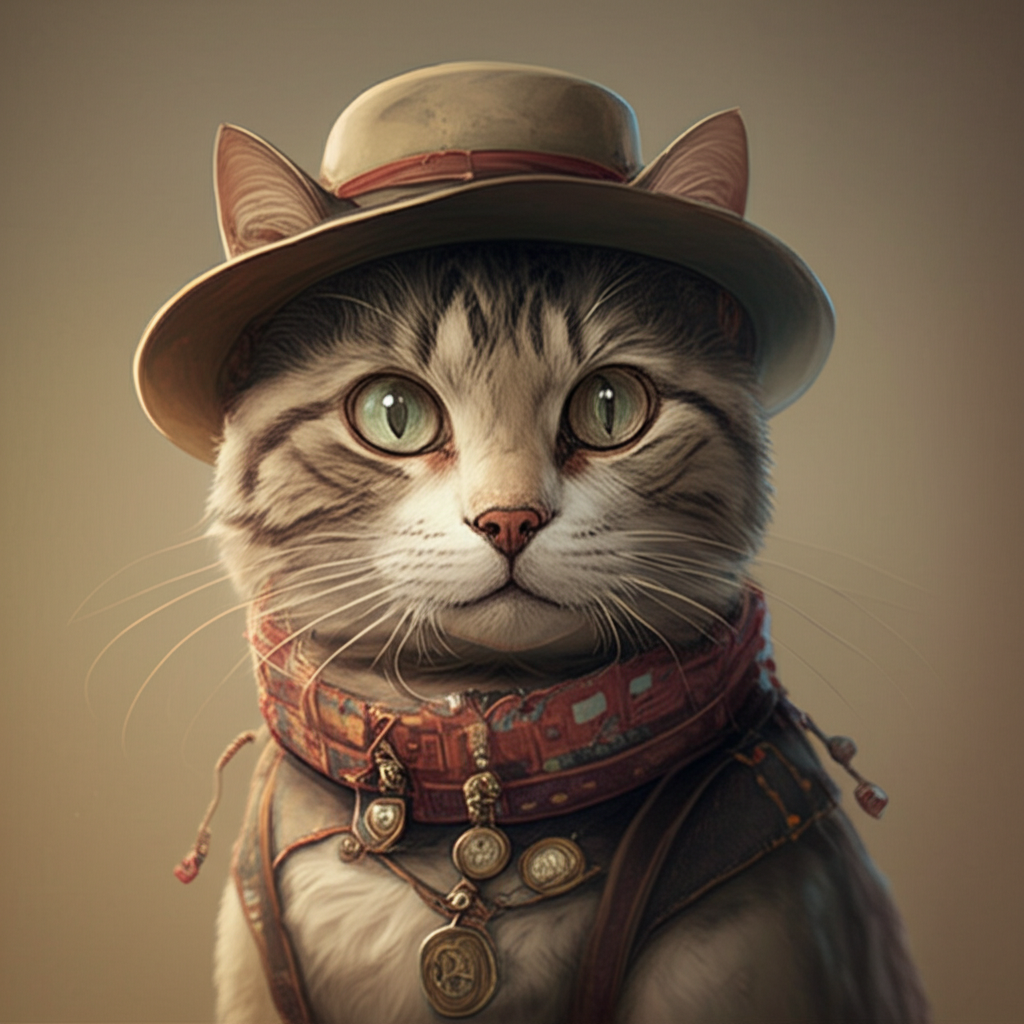

In [2]:
import base64
from io import BytesIO

from IPython.display import Image, display
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-exp-image-generation")

message = {
    "role": "user",
    "content": "Generate an image of a cuddly cat wearing a hat.",
}

response = llm.invoke(
    [message],
    generation_config=dict(response_modalities=["TEXT", "IMAGE"]),
)

image_base64 = response.content[0].get("image_url").get("url").split(",")[-1]

image_data = base64.b64decode(image_base64)
display(Image(data=image_data, width=300))

### Image and text to image

You can iterate on an image in a multi-turn conversation, as shown below:

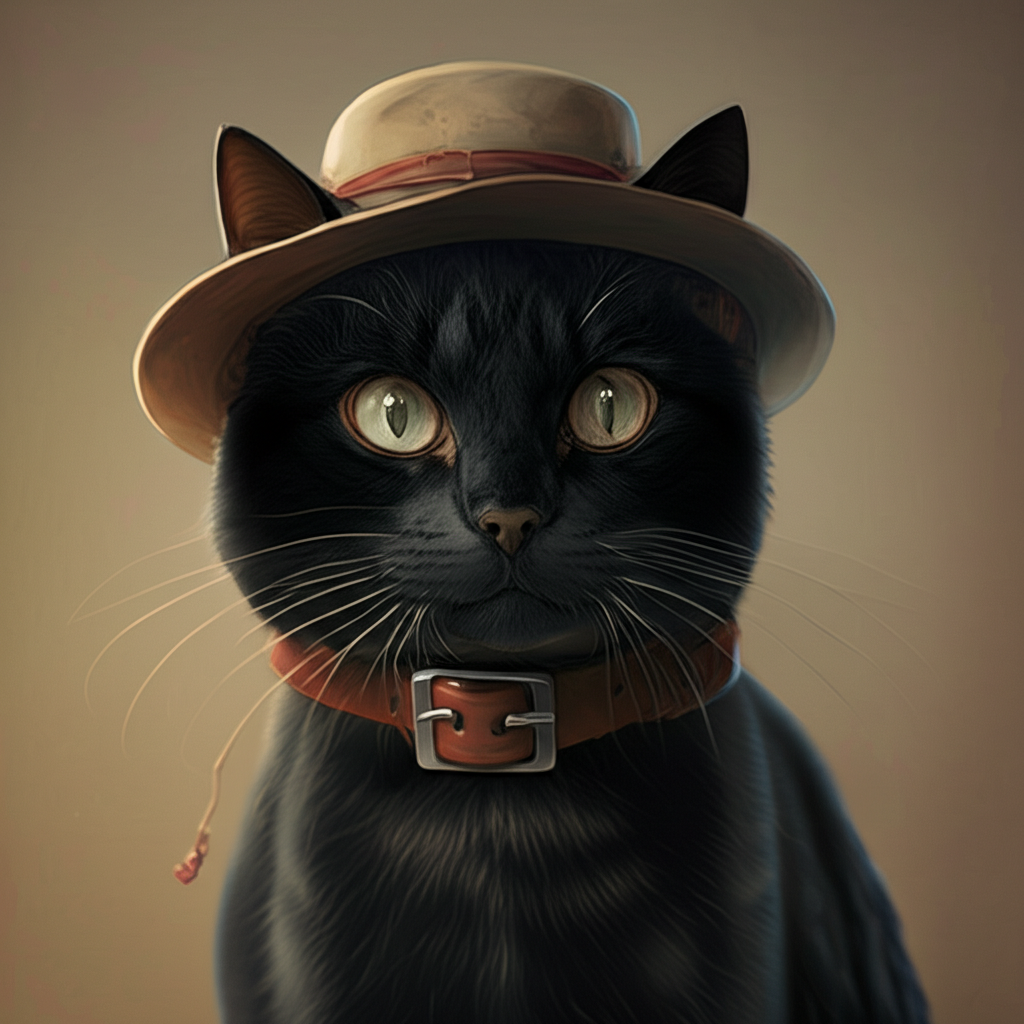

In [3]:
next_message = {
    "role": "user",
    "content": "Can you take the same image and make the cat black?",
}

response = llm.invoke(
    [message, response, next_message],
    generation_config=dict(response_modalities=["TEXT", "IMAGE"]),
)

image_base64 = response.content[0].get("image_url").get("url").split(",")[-1]

image_data = base64.b64decode(image_base64)
display(Image(data=image_data, width=300))

You can also represent an input image and query in a single message by encoding the base64 data in the [data URI scheme](https://en.wikipedia.org/wiki/Data_URI_scheme):

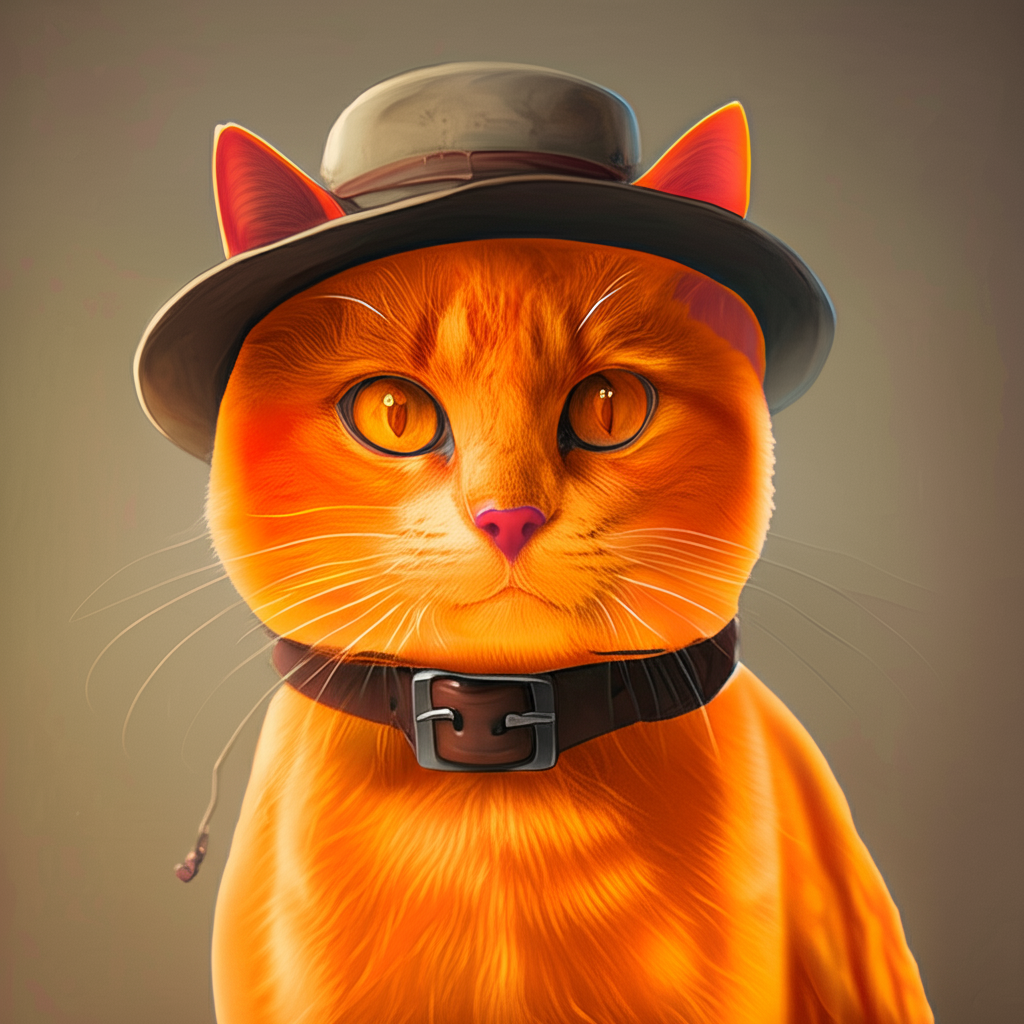

In [9]:
message = {
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": "Can you make this cat bright orange?",
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{image_base64}"},
        },
    ],
}

response = llm.invoke(
    [message],
    generation_config=dict(response_modalities=["TEXT", "IMAGE"]),
)
image_base64 = response.content[0].get("image_url").get("url").split(",")[-1]

image_data = base64.b64decode(image_base64)
display(Image(data=image_data, width=300))

You can also use LangGraph to manage the conversation history for you as in [this tutorial](/docs/tutorials/chatbot/).

## Safety Settings

Gemini models have default safety settings that can be overridden. If you are receiving lots of "Safety Warnings" from your models, you can try tweaking the `safety_settings` attribute of the model. For example, to turn off safety blocking for dangerous content, you can construct your LLM as follows:

In [14]:
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
    HarmBlockThreshold,
    HarmCategory,
)

llm = ChatGoogleGenerativeAI(
    model="gemini-1.5-pro",
    safety_settings={
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    },
)

For an enumeration of the categories and thresholds available, see Google's [safety setting types](https://ai.google.dev/api/python/google/generativeai/types/SafetySettingDict).

## API reference

For detailed documentation of all ChatGoogleGenerativeAI features and configurations head to the API reference: https://python.langchain.com/api_reference/google_genai/chat_models/langchain_google_genai.chat_models.ChatGoogleGenerativeAI.html